<a href="https://colab.research.google.com/github/himanshubhimte69/Parameter_Efficient_Deep_Learning-Class_Selective_Knowledge_Distillation_for_Precision_Agriculture/blob/main/epochs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip Plant_Pathology_2020.zip

Archive:  Plant_Pathology_2020.zip
   creating: Plant Pathology 2020/
   creating: Plant Pathology 2020/Images/
   creating: Plant Pathology 2020/Images/healthy/
  inflating: Plant Pathology 2020/Images/healthy/Train_100.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1001.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1002.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1004.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1005.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1007.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1012.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1014.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1017.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1020.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_103.jpg  
  inflating: Plant Pathology 2020/Images/healthy/Train_1031.jpg  
  inflating: Plant Pathology 2020/Images/healthy

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense
)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


In [ ]:
IMG_SIZE = (224,224)

BATCH_SIZE = 16

EPOCHS = 3

In [ ]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Plant Pathology 2020/Images",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.2,
    subset="training",
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Plant Pathology 2020/Images",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    validation_split=0.2,
    subset="validation",
    seed=42
)

print("Dataset loaded")

Found 1730 files belonging to 3 classes.
Using 1384 files for training.
Found 1730 files belonging to 3 classes.
Using 346 files for validation.
Dataset loaded


In [ ]:
# ============================================================
# 4. BUILD BASELINE MODEL
# ============================================================

baseline_base = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)
baseline_model = tf.keras.Sequential([
    baseline_base,
    GlobalAveragePooling2D(),
    Dense(
        3,
        activation='softmax'
    )
])

baseline_model.build(
    (None,224,224,3)
)
# ============================================================
# LOAD BASELINE WEIGHTS
# ============================================================

baseline_model.load_weights(
    "/content/basemodel_model_pp2020.h5",
    by_name=True,
    skip_mismatch=True
)

print("Baseline model loaded")

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Baseline model loaded


In [ ]:
# ============================================================
# FREEZE MOST BACKBONE LAYERS
# ============================================================

for layer in baseline_base.layers[:-30]:

    layer.trainable = False

In [ ]:
# ============================================================
# 5. COMPILE BASELINE MODEL
# ============================================================

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ============================================================
# 6. TRAIN BASELINE MODEL
# ============================================================

print("\n================================================")
print("TRAINING BASELINE MODEL")
print("================================================")

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


TRAINING BASELINE MODEL
Epoch 1/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 137s 885ms/step - accuracy: 0.5303 - loss: 0.9958 - val_accuracy: 0.6618 - val_loss: 0.9059
Epoch 2/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 16s 189ms/step - accuracy: 0.7204 - loss: 0.8114 - val_accuracy: 0.7197 - val_loss: 0.7530
Epoch 3/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 19s 172ms/step - accuracy: 0.7941 - loss: 0.6886 - val_accuracy: 0.7601 - val_loss: 0.6493


In [ ]:
# ============================================================
# 7. BUILD KD STUDENT MODEL
# ============================================================

kd_base = EfficientNetB4(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

student_model_pp2020 = tf.keras.Sequential([
    kd_base,
    GlobalAveragePooling2D(),
    Dense(
        3,
        activation='softmax'
    )
])

student_model_pp2020.build(
    (None,224,224,3)
)

# ============================================================
# LOAD KD WEIGHTS
# ============================================================

student_model_pp2020.load_weights(
    "/content/student_model_pp2020.h5",
    by_name=True,
    skip_mismatch=True
)

print("KD student model loaded")


KD student model loaded


In [ ]:
# ============================================================
# FREEZE MOST KD BACKBONE LAYERS
# ============================================================

for layer in kd_base.layers[:-30]:

    layer.trainable = False

In [ ]:
# ============================================================
# 8. COMPILE KD MODEL
# ============================================================

student_model_pp2020.compile(
    optimizer=tf.keras.optimizers.Adam(
        1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# ============================================================
# 9. TRAIN KD MODEL
# ============================================================

print("\n================================================")
print("TRAINING KD STUDENT MODEL")
print("================================================")

kd_history = student_model_pp2020.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


TRAINING KD STUDENT MODEL
Epoch 1/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 113s 728ms/step - accuracy: 0.7175 - loss: 0.7790 - val_accuracy: 0.9017 - val_loss: 0.5115
Epoch 2/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - accuracy: 0.9357 - loss: 0.3670 - val_accuracy: 0.9249 - val_loss: 0.3093
Epoch 3/3
87/87 ━━━━━━━━━━━━━━━━━━━━ 17s 198ms/step - accuracy: 0.9581 - loss: 0.2350 - val_accuracy: 0.9306 - val_loss: 0.2384


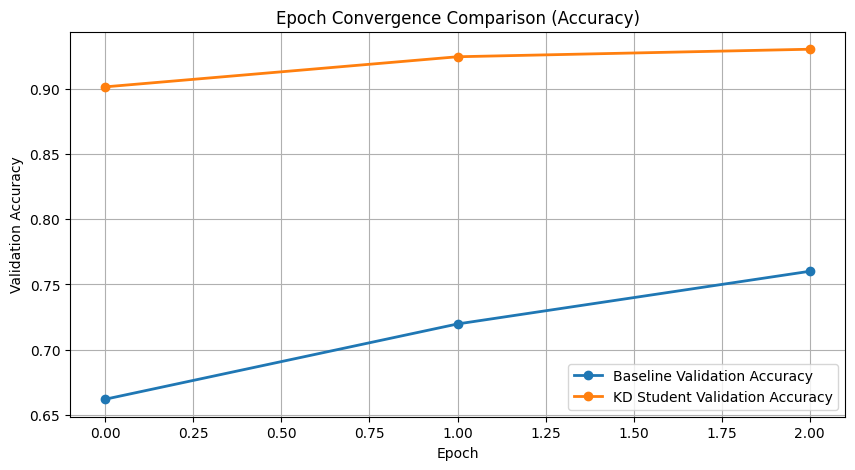

In [ ]:
# ============================================================
# 10. ACCURACY PLOT
# ============================================================

fig1 = plt.figure(figsize=(10,5))

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------

plt.plot(
    baseline_history.history['val_accuracy'],
    marker='o',
    linewidth=2,
    label='Baseline Validation Accuracy'
)

# ------------------------------------------------------------
# KD STUDENT
# ------------------------------------------------------------

plt.plot(
    kd_history.history['val_accuracy'],
    marker='o',
    linewidth=2,
    label='KD Student Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.title(
    "Epoch Convergence Comparison (Accuracy)"
)

plt.legend()

plt.grid(True)

accuracy_path = "/content/convergence_accuracy.png"

fig1.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()


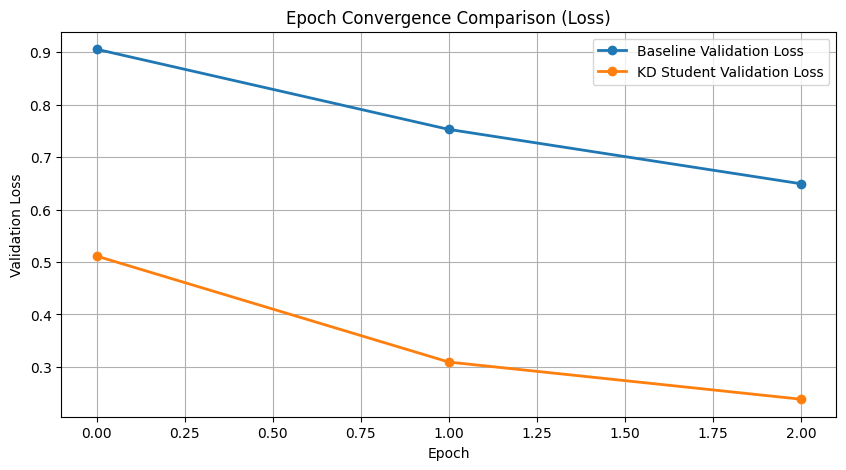

In [ ]:
# ============================================================
# 11. LOSS PLOT
# ============================================================

fig2 = plt.figure(figsize=(10,5))

# ------------------------------------------------------------
# BASELINE
# ------------------------------------------------------------

plt.plot(
    baseline_history.history['val_loss'],
    marker='o',
    linewidth=2,
    label='Baseline Validation Loss'
)

# ------------------------------------------------------------
# KD STUDENT
# ------------------------------------------------------------

plt.plot(
    kd_history.history['val_loss'],
    marker='o',
    linewidth=2,
    label='KD Student Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title(
    "Epoch Convergence Comparison (Loss)"
)

plt.legend()

plt.grid(True)

loss_path = "/content/convergence_loss.png"

fig2.savefig(
    loss_path,
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [ ]:
# ============================================================
# 12. FINAL METRICS
# ============================================================

print("\n================================================")
print("FINAL RESULTS")
print("================================================")

print("\nBaseline Final Validation Accuracy:")
print(
    baseline_history.history['val_accuracy'][-1]
)

print("\nKD Student Final Validation Accuracy:")
print(
    kd_history.history['val_accuracy'][-1]
)



FINAL RESULTS

Baseline Final Validation Accuracy:
0.7601156234741211

KD Student Final Validation Accuracy:
0.9306358098983765


In [ ]:
# ============================================================
# 13. DOWNLOAD RESULTS
# ============================================================

from google.colab import files

files.download(
    accuracy_path
)

files.download(
    loss_path
)

print("\n================================================")
print("CONVERGENCE EXPERIMENT COMPLETED")
print("================================================")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


CONVERGENCE EXPERIMENT COMPLETED
